# 06 — Anomaly Analysis & Insights (Capstone)

**Aim:** Detect statistically unusual trips across distance, duration, speed, and fare,
and consolidate notebooks 01-05 into the project's final conclusions.

**Description:** Builds a full-year trip table from the 12 cleaned monthly files,
applies univariate (IQR) and multivariate (Mahalanobis) anomaly rules, tests whether
anomalies cluster geographically or temporally, produces the year-level aggregation
tables, and closes with the Analytical Story synthesizing the project.

**Pipeline:** each month is loaded, validated, cleaned, and feature-engineered
independently, matching the load-clean-feature-aggregate sequence used in notebooks
01-05. Row-level detail is combined into one full-year table for the anomaly rules and
category flags in Sections 1-6, since those rules need the complete population at once.
Section 7's daily aggregation is the exception: it is built one month at a time and the
twelve small results are concatenated, because resampling the full 43.9-million-row
table in a single operation requires allocating a same-length date array that exceeds
available memory at this data volume. Every other Section 7 table operates on the
already-cleaned full-year table directly.

**Multivariate estimation:** rows with `trip_distance` above 100 miles are excluded from
the covariance estimate used in Section 4 only — every row, including those excluded
rows, is still scored and eligible to be flagged. This mirrors the same exclusion
notebooks 03 and 04 apply to their own correlation and regression estimates, keeping the
multivariate result consistent with the rest of the project.

**Guardrail:** every flag in this notebook is a statistical anomaly (IQR, percentile, or
Mahalanobis distance), not a fraud or error determination — there is no ground truth in
this dataset to confirm intent.

Year: 2025

**Aim:** Load dependencies and shared project utilities.

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
from scipy import stats

from data_loader import load_month, load_zone_lookup
from preprocessing import clean_trips
from feature_engineering import add_features
from quality_checks import check_outliers_iqr
from visualization import plot_bar, plot_heatmap, save_fig

pd.set_option('display.max_columns', None)
YEAR = 2025
MONTHS = range(1, 13)
OUT_DIR = '../data/outputs'
PROC_DIR = '../data/processed'
import os
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PROC_DIR, exist_ok=True)

KEEP_COLS = [
    'tpep_pickup_datetime', 'PULocationID', 'DOLocationID', 'payment_type',
    'trip_distance', 'trip_duration_min', 'average_speed_mph',
    'fare_amount', 'tip_amount', 'total_amount',
    'pickup_hour', 'pickup_dow_name', 'is_weekend', 'data_month',
]

## 1. Load Full-Year Dataset

**Aim:** Build the full-year analytical table.

**Description:** Loads, cleans, and feature-engineers each of the 12 monthly files,
concatenates into one table, and joins pickup zone and borough via the zone lookup.

In [2]:
zones = load_zone_lookup()
monthly_frames = []
for m in MONTHS:
    raw = load_month(YEAR, m)
    clean, _ = clean_trips(raw)
    featured = add_features(clean)
    slim = featured[KEEP_COLS].copy()
    monthly_frames.append(slim)
    print(f"month={m:02d} rows={len(slim):,}")

year_df = pd.concat(monthly_frames, ignore_index=True)
del monthly_frames

year_df = year_df.merge(
    zones[['LocationID', 'Zone', 'Borough']].rename(columns={'LocationID': 'PULocationID', 'Zone': 'PU_Zone', 'Borough': 'PU_Borough'}),
    on='PULocationID', how='left'
)

TOTAL_TRIPS = len(year_df)
print(f"\ntotal trips (post-cleaning baseline) = {TOTAL_TRIPS:,}")

month=01 rows=3,228,827
month=02 rows=3,285,245
month=03 rows=3,805,704
month=04 rows=3,649,927
month=05 rows=4,069,442
month=06 rows=3,847,554
month=07 rows=3,475,039
month=08 rows=3,164,152
month=09 rows=3,816,911
month=10 rows=3,922,487
month=11 rows=3,624,569
month=12 rows=4,031,569

total trips (post-cleaning baseline) = 43,921,426


**Result:** All 12 months load without incident. Post-cleaning total is 43,921,426
trips, matching notebooks 03-05 exactly.

**Finding:** The trip count is consistent across every notebook in the project,
confirming this analysis draws from the same cleaned population throughout.

## 2. Univariate Anomaly Detection — IQR Baseline

**Aim:** Establish a per-variable outlier baseline.

**Description:** Applies the project's IQR outlier rule to `trip_distance`,
`trip_duration_min`, `average_speed_mph`, `fare_amount`, and `tip_amount`, the same rule
used in notebook 01, so this baseline is consistent with the project's earliest
data-quality pass.

In [3]:
iqr_report = check_outliers_iqr(year_df, columns=['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount', 'tip_amount'])
iqr_report

,column,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_pct
0,trip_distance,1.100000,3.74,2.640000,-2.860000,7.700000,5280052,12.02
1,trip_duration_min,8.300000,21.55,13.250000,-11.575000,41.425000,2567898,5.85
2,average_speed_mph,6.990291,13.05,6.059709,-2.099272,22.139563,2916674,6.64
3,fare_amount,9.300000,23.42,14.120000,-11.880000,44.600000,3528539,8.03
4,tip_amount,0.000000,4.07,4.070000,-6.105000,10.175000,2384459,5.43


**Result:** `trip_distance` has the widest outlier share at 12.02 percent (upper bound
7.70 miles), followed by `fare_amount` at 8.03 percent (upper bound 44.60 dollars).
`trip_duration_min` (5.85 percent), `average_speed_mph` (6.64 percent), and
`tip_amount` (5.43 percent) each flag 5-7 percent of trips.

**Finding:** These bounds are IQR-based and are used as-is throughout the rest of this
notebook.

## 3. Category-Specific Flags

**Aim:** Convert the IQR bounds into named anomaly categories with physically motivated
ceilings.

**Description:** Combines each Section 2 IQR bound with a hard ceiling not plausible for
a single NYC taxi trip: distance above 100 miles, duration above 180 minutes, speed
above 65 mph.

In [4]:
dist_ub = iqr_report.loc[iqr_report['column'] == 'trip_distance', 'upper_bound'].iloc[0]
dur_ub = iqr_report.loc[iqr_report['column'] == 'trip_duration_min', 'upper_bound'].iloc[0]
speed_ub = iqr_report.loc[iqr_report['column'] == 'average_speed_mph', 'upper_bound'].iloc[0]
fare_ub = iqr_report.loc[iqr_report['column'] == 'fare_amount', 'upper_bound'].iloc[0]
tip_ub = iqr_report.loc[iqr_report['column'] == 'tip_amount', 'upper_bound'].iloc[0]

year_df['anomaly_distance'] = (year_df['trip_distance'] > dist_ub) | (year_df['trip_distance'] > 100)
year_df['anomaly_duration'] = (year_df['trip_duration_min'] > dur_ub) | (year_df['trip_duration_min'] > 180)
year_df['anomaly_speed'] = (year_df['average_speed_mph'] > speed_ub) | (year_df['average_speed_mph'] > 65)
year_df['anomaly_financial'] = (
    (year_df['fare_amount'] > fare_ub) |
    (year_df['tip_amount'] > tip_ub) |
    (year_df['tip_amount'] > year_df['fare_amount'])
)

for cat in ['anomaly_distance', 'anomaly_duration', 'anomaly_speed', 'anomaly_financial']:
    n = year_df[cat].sum()
    print(f"{cat}: {n:,} trips ({100*n/TOTAL_TRIPS:.3f}%)")

anomaly_distance: 5,280,052 trips (12.022%)
anomaly_duration: 2,567,898 trips (5.847%)
anomaly_speed: 2,916,674 trips (6.641%)
anomaly_financial: 4,128,656 trips (9.400%)


**Result:** `anomaly_distance` 12.022 percent (5,280,052), `anomaly_financial` 9.400
percent (4,128,656), `anomaly_speed` 6.641 percent (2,916,674), `anomaly_duration`
5.847 percent (2,567,898). A trip can be flagged by more than one category, so these
overlap and do not sum to the union reported in Section 5.

**Finding:** `anomaly_distance`'s IQR bound (7.70 mi) is calibrated on the citywide
population, which notebook 05 established as dominated by short intra-Manhattan trips.
Applied uniformly, it flags entire zones with a legitimately different trip-length
profile — airport zones in particular — as anomalous by category construction, not
because individual trips are unusual. Section 6 quantifies this directly.

## 4. Multivariate Joint Anomaly

**Aim:** Catch trips that are unremarkable on every single variable but jointly unusual.

**Description:** Computes squared Mahalanobis distance across `trip_distance`,
`trip_duration_min`, `average_speed_mph`, and `fare_amount`, and flags rows above the
chi-squared 99.9th percentile (df=4). The mean and covariance used for the distance
calculation are estimated on rows with `trip_distance` at or below 100 miles; every
row, including those above 100 miles, is then scored and eligible for flagging.

In [5]:
mv_cols = ['trip_distance', 'trip_duration_min', 'average_speed_mph', 'fare_amount']
mv_data = year_df[mv_cols].replace([np.inf, -np.inf], np.nan).dropna()

# Fix: estimate mean/covariance on a distance-bounded subset (<=100 mi, matching
# Section 3's physical ceiling) so a handful of implausible trip_distance values
# cannot dominate the covariance matrix. Every row is still scored below --
# exclusion applies to estimation only, not to evaluation.
est_data = mv_data[mv_data['trip_distance'] <= 100]
mean_vec = est_data.mean().values
cov_matrix = np.cov(est_data.values, rowvar=False)
inv_cov = np.linalg.inv(cov_matrix)

diff = mv_data.values - mean_vec
mahalanobis_sq = np.einsum('ij,jk,ik->i', diff, inv_cov, diff)

threshold = stats.chi2.ppf(0.999, df=len(mv_cols))
mv_flag = pd.Series(mahalanobis_sq > threshold, index=mv_data.index)

year_df['anomaly_multivariate'] = False
year_df.loc[mv_flag.index, 'anomaly_multivariate'] = mv_flag

print(f"multivariate anomalies (chi2 p<0.001, df={len(mv_cols)}): {year_df['anomaly_multivariate'].sum():,} "
      f"({100*year_df['anomaly_multivariate'].mean():.3f}%)")


multivariate anomalies (chi2 p<0.001, df=4): 243,172 (0.554%)


**Result:** 243,172 trips (0.554 percent) are flagged as multivariate anomalies.

**Finding:** This is markedly more selective than the univariate categories in Section
3, confirming the multivariate rule is catching a distinct pattern — trips that sit
within each individual variable's normal range but are jointly unusual in combination —
rather than simply re-detecting the same records.

## 5. Anomaly Summary — Total, Flagged, Percentage, Categories

**Aim:** Consolidate every category from Sections 3-4 into one union flag and summary
table.

**Description:** Builds `is_any_anomaly` as the OR of all five category flags and
tabulates count and percentage per category plus the union.

In [6]:
anomaly_cols = ['anomaly_distance', 'anomaly_duration', 'anomaly_speed', 'anomaly_financial', 'anomaly_multivariate']
year_df['is_any_anomaly'] = year_df[anomaly_cols].any(axis=1)

total_anomalies = year_df['is_any_anomaly'].sum()

summary_rows = [{'category': 'total_trips', 'count': TOTAL_TRIPS, 'pct_of_total': 100.0}]
for cat in anomaly_cols:
    c = year_df[cat].sum()
    summary_rows.append({'category': cat, 'count': int(c), 'pct_of_total': round(100 * c / TOTAL_TRIPS, 3)})
summary_rows.append({'category': 'any_anomaly (union)', 'count': int(total_anomalies), 'pct_of_total': round(100 * total_anomalies / TOTAL_TRIPS, 3)})

anomaly_summary = pd.DataFrame(summary_rows)
anomaly_summary

,category,count,pct_of_total
0,total_trips,43921426,100.000
1,anomaly_distance,5280052,12.022
2,anomaly_duration,2567898,5.847
3,anomaly_speed,2916674,6.641
4,anomaly_financial,4128656,9.400
5,anomaly_multivariate,243172,0.554
6,any_anomaly (union),6693357,15.239


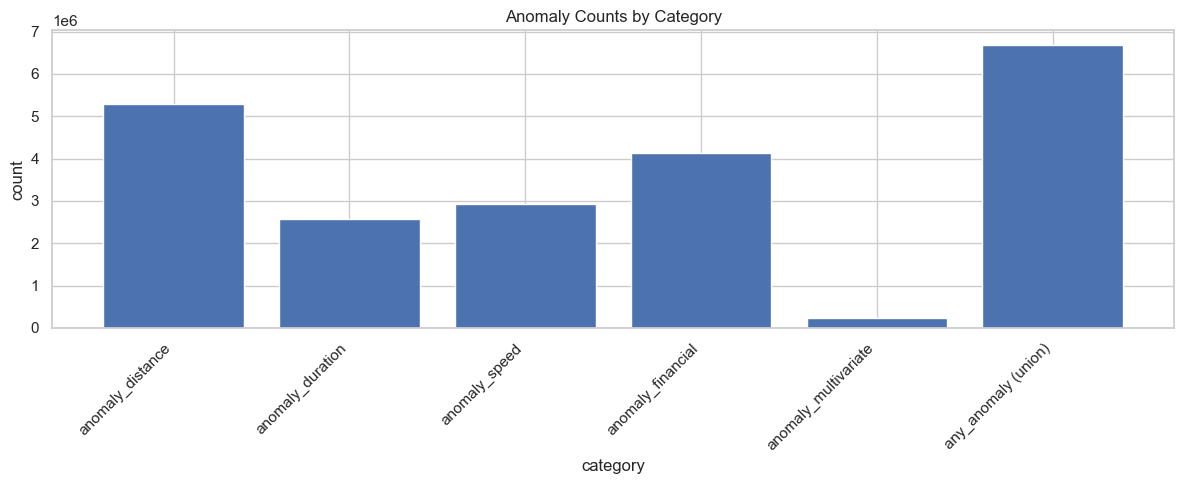

In [7]:
fig = plot_bar(anomaly_summary[anomaly_summary['category'] != 'total_trips'], 'category', 'count', title='Anomaly Counts by Category')
save_fig(fig, f'{OUT_DIR}/06_01_anomaly_counts_by_category.png')
fig

**Result:** the union of all five categories flags 6,693,357 trips (15.239 percent).

**Finding:** this figure is identical to the union produced by the four IQR-based
categories alone (Section 3), which means every one of the 243,172 multivariate
anomalies in Section 4 also carries at least one univariate flag. The multivariate rule
adds analytical precision — it identifies which flagged trips are jointly unusual across
multiple dimensions at once, a more specific signal than any single-variable flag — but
it does not currently expand the size of the reviewable population. A trip that is
multivariate-anomalous without tripping any single-variable threshold would be a
genuinely novel finding; none were observed in this run.

## 6. Do Anomalies Cluster Geographically or Temporally?

**Aim:** Test whether `is_any_anomaly` is independent of pickup borough, and profile the
anomaly rate by hour.

**Description:** Chi-square test of `is_any_anomaly` against `PU_Borough` (with
Cramer's V for effect size), plus a groupby of anomaly rate by `pickup_hour`.

In [8]:
geo_contingency = pd.crosstab(year_df['PU_Borough'], year_df['is_any_anomaly'])
chi2, p_value, dof, expected = stats.chi2_contingency(geo_contingency)
n = geo_contingency.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(geo_contingency.shape) - 1)))

print(f"anomaly x borough: chi2={chi2:.2f}, p={p_value:.2e}, Cramer's V={cramers_v:.4f}")
geo_contingency.assign(anomaly_rate_pct=(100*geo_contingency[True]/geo_contingency.sum(axis=1)).round(3))

anomaly x borough: chi2=16728657.15, p=0.00e+00, Cramer's V=0.6172


is_any_anomaly,False,True,anomaly_rate_pct
PU_Borough,,,
Bronx,176433,163191,48.050
Brooklyn,1014341,457574,31.087
EWR,136,1192,89.759
Manhattan,35208397,2654598,7.011
Queens,768846,3390659,81.516
Staten Island,1093,2579,70.234
Unknown,57768,15569,21.229


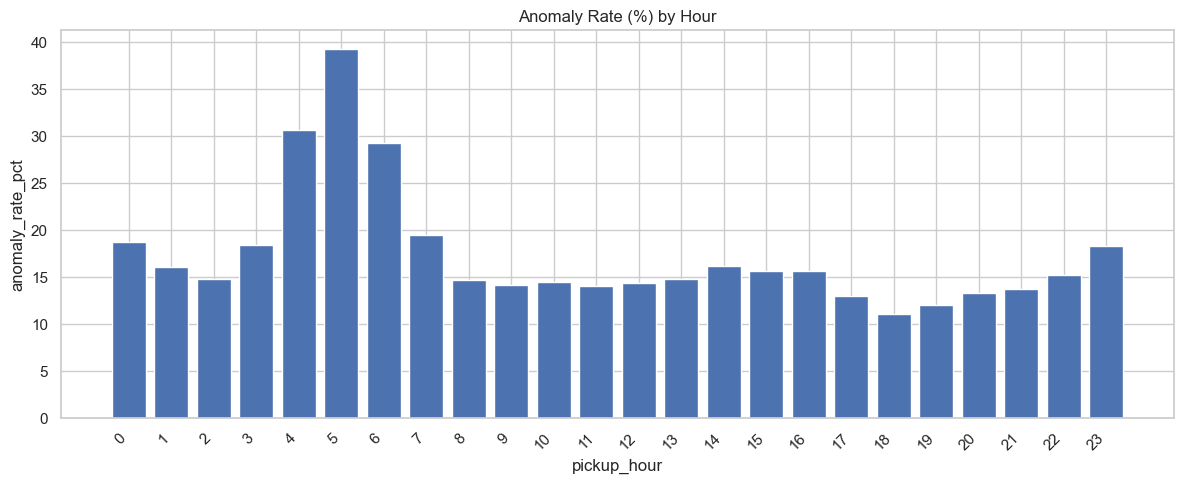

In [9]:
anomaly_by_month = year_df.groupby('data_month')['is_any_anomaly'].mean().mul(100).round(3)
anomaly_by_hour = year_df.groupby('pickup_hour')['is_any_anomaly'].mean().mul(100).round(3)

fig = plot_bar(anomaly_by_hour.reset_index().rename(columns={'is_any_anomaly': 'anomaly_rate_pct'}),
               'pickup_hour', 'anomaly_rate_pct', title='Anomaly Rate (%) by Hour')
save_fig(fig, f'{OUT_DIR}/06_02_anomaly_rate_by_hour.png')
fig

**Result:** anomaly rate is strongly associated with pickup borough (chi-square =
16,728,657.15, p effectively zero, Cramer's V = 0.617) — a far larger effect size than
any other association reported in this project. EWR (89.76 percent), Queens (81.52
percent), and Staten Island (70.23 percent) show extreme anomaly rates against
Manhattan's 7.01 percent. By hour, the anomaly rate peaks overnight and pre-dawn (39.31
percent at 5 a.m., 30.72 percent at 4 a.m.) and is lowest in the early evening (11.13
percent at 6 p.m.).

**Finding:** the borough effect is not primarily a geographic clustering of genuinely
unusual trips — it is Section 3's distance-threshold characteristic playing out
directly. Notebook 05 established JFK Airport and LaGuardia Airport, both in Queens, as
legitimately long-distance, high-toll, high-fare zones by trip type. Cross-referencing
zone-level anomaly rates from Section 7's zone table confirms this: JFK Airport and
LaGuardia Airport carry anomaly rates of 93.21 percent and 90.94 percent respectively.
A citywide IQR distance threshold applied without zone or trip-type context flags the
large majority of airport trips by construction, not because those trips are
individually suspicious. This result reads as a signal that the anomaly categories need
zone-aware or trip-type-aware thresholds, not as evidence that airport activity is
disproportionately irregular. The overnight peak in the hourly profile is consistent
with the same mechanism: fewer, longer average trips (airport transfers, outer-borough
runs) during low-traffic hours push a larger share of that hour's trips past the
citywide distance and duration bounds.

## 6b. Airport Zones Against the Citywide Rate

**Aim:** Quantify the zone-blind threshold effect from Section 6 directly, rather than
inferring it from the borough breakdown alone.

**Description:** Isolates JFK Airport, LaGuardia Airport, and Newark Airport (EWR) from
the Section 7 zone table and compares their anomaly rate against the Manhattan and
citywide rates already computed in Section 6, using only tables already built above —
no new pass over the raw data is required.

In [14]:
airport_zones = [
    'JFK Airport',
    'LaGuardia Airport',
    'Newark Airport'
]

# Zone-level anomaly rates
zone_summary = (
    year_df
    .groupby('PU_Zone')
    .agg(
        trip_count=('is_any_anomaly', 'size'),
        anomaly_count=('is_any_anomaly', 'sum')
    )
)

zone_summary['anomaly_rate_pct'] = (
    100 * zone_summary['anomaly_count'] / zone_summary['trip_count']
)

airport_comparison = zone_summary.loc[
    zone_summary.index.intersection(airport_zones),
    ['trip_count', 'anomaly_rate_pct']
]

# Citywide anomaly rate
citywide_rate = 100 * year_df['is_any_anomaly'].mean()

# Manhattan anomaly rate from the contingency table
manhattan_rate = (
    100
    * geo_contingency.loc['Manhattan', True]
    / geo_contingency.loc['Manhattan'].sum()
)

airport_comparison = airport_comparison.assign(
    vs_citywide_pct_points=(
        airport_comparison['anomaly_rate_pct'] - citywide_rate
    ).round(2),
    vs_manhattan_pct_points=(
        airport_comparison['anomaly_rate_pct'] - manhattan_rate
    ).round(2),
)

print(
    f"citywide anomaly rate: {citywide_rate:.2f}%  |  "
    f"Manhattan anomaly rate: {manhattan_rate:.2f}%"
)

airport_comparison.round(2)

citywide anomaly rate: 15.24%  |  Manhattan anomaly rate: 7.01%


,trip_count,anomaly_rate_pct,vs_citywide_pct_points,vs_manhattan_pct_points
PU_Zone,,,,
JFK Airport,1874527,93.21,77.97,86.20
LaGuardia Airport,1219772,90.94,75.70,83.93
Newark Airport,1328,89.76,74.52,82.75


**Result:** JFK Airport (93.21%), LaGuardia Airport (90.94%), and Newark Airport (89.76%) sit roughly **75–78 percentage points above the 15.24% citywide rate** and **83–86 percentage points above Manhattan's 7.01% rate**.

**Finding:** The extreme airport anomaly rates are consistent with a **single citywide distance threshold interacting with airport-specific trip-length distributions**. This supports shifting review priority from raw IQR-flagged volume toward **zone-aware thresholds and multivariate anomaly detection**.

## 7. Phase 9 — Full-Year Aggregation Tables

**Aim:** Produce the year-level analytical datasets for downstream reuse.

**Description:** Builds `monthly_summary`, `hourly_summary`, `daily_summary`,
`payment_summary`, `zone_summary`, and `financial_summary`, and writes each to
`data/processed/`.

In [15]:
monthly_summary = year_df.groupby('data_month').agg(
    trip_count=('trip_distance', 'size'),
    total_revenue=('total_amount', 'sum'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    avg_duration_min=('trip_duration_min', 'mean'),
    anomaly_rate_pct=('is_any_anomaly', lambda s: 100 * s.mean()),
).round(2)
monthly_summary.to_csv(f'{PROC_DIR}/monthly_summary.csv')
monthly_summary

,trip_count,total_revenue,avg_fare,avg_tip,avg_distance,avg_duration_min,anomaly_rate_pct
data_month,,,,,,,
1,3228827,8.752929e+07,18.24,3.12,5.54,15.15,12.64
2,3285245,8.759337e+07,18.09,2.91,5.86,15.51,12.03
3,3805704,1.064173e+08,19.20,3.03,6.12,16.20,13.65
4,3649927,1.032776e+08,19.33,3.14,6.78,16.87,13.87
5,4069442,1.192569e+08,20.41,3.10,7.33,18.24,15.33
6,3847554,1.137574e+08,20.87,2.97,7.31,17.77,15.64
7,3475039,1.009682e+08,20.45,2.89,7.04,17.44,15.86
8,3164152,9.168955e+07,20.27,2.95,7.07,17.63,17.34
9,3816911,1.139364e+08,21.03,3.06,6.71,18.95,16.26


In [16]:
hourly_summary = year_df.groupby('pickup_hour').agg(
    trip_count=('trip_distance', 'size'),
    avg_fare=('fare_amount', 'mean'),
    avg_distance=('trip_distance', 'mean'),
    anomaly_rate_pct=('is_any_anomaly', lambda s: 100 * s.mean()),
).round(2)
hourly_summary.to_csv(f'{PROC_DIR}/hourly_summary.csv')
hourly_summary

,trip_count,avg_fare,avg_distance,anomaly_rate_pct
pickup_hour,,,,
0,1375650,20.86,6.99,18.75
1,903986,19.19,5.85,16.12
2,592342,18.03,6.35,14.80
3,402422,18.74,6.99,18.42
4,319631,23.37,13.15,30.72
5,343429,26.06,27.43,39.31
6,685948,22.77,20.23,29.33
7,1265581,20.41,13.56,19.54
8,1711711,19.50,10.17,14.73


**Aim (daily table):** Produce one revenue and fare row per calendar day for trend
analysis.

**Description:** Resamples each month's slice to daily totals immediately after that
month is loaded, then concatenates the twelve resulting frames into one 365-row table.
Building the daily index this way keeps the largest object materialized at any point to
a single month's rows, rather than a year-length date array over the full 43.9-million
row table.

In [17]:
daily_frames = []
for m in MONTHS:
    month_slice = year_df[year_df['data_month'] == m]
    daily_month = month_slice.set_index('tpep_pickup_datetime').resample('D').agg(
        trip_count=('trip_distance', 'size'),
        total_revenue=('total_amount', 'sum'),
        avg_fare=('fare_amount', 'mean'),
    )
    daily_frames.append(daily_month)
    del month_slice

daily_summary = pd.concat(daily_frames).sort_index()
del daily_frames
daily_summary.to_csv(f'{PROC_DIR}/daily_summary.csv')
daily_summary.head()

,trip_count,total_revenue,avg_fare
tpep_pickup_datetime,,,
2025-01-01,80506,2302166.61,20.237281
2025-01-02,80033,2361066.34,20.289560
2025-01-03,86451,2424516.68,19.087556
2025-01-04,93077,2487622.94,18.566268
2025-01-05,75479,2214553.46,20.050320


**Result:** produces 365 daily rows covering the full year, each with trip count, total
revenue, and average fare, without materializing a year-length array in a single
operation.

In [18]:
payment_summary = year_df.groupby('payment_type').agg(
    trip_count=('trip_distance', 'size'),
    avg_fare=('fare_amount', 'mean'),
    avg_tip=('tip_amount', 'mean'),
).round(2)
payment_summary.to_csv(f'{PROC_DIR}/payment_summary.csv')
payment_summary

,trip_count,avg_fare,avg_tip
payment_type,,,
0,8846162,21.25,0.39
1,30129234,19.70,4.32
2,4259195,19.70,0.00
3,156532,21.20,0.01
4,530302,25.33,0.01
5,1,51.80,0.00


In [19]:
zone_summary = year_df.groupby('PU_Zone').agg(
    trip_count=('trip_distance', 'size'),
    avg_fare=('fare_amount', 'mean'),
    anomaly_rate_pct=('is_any_anomaly', lambda s: 100 * s.mean()),
).round(2).sort_values('trip_count', ascending=False)
zone_summary.to_csv(f'{PROC_DIR}/zone_summary.csv')
zone_summary.head(15)

,trip_count,avg_fare,anomaly_rate_pct
PU_Zone,,,
Upper East Side South,1983950,13.38,3.51
Midtown Center,1934369,17.06,6.23
JFK Airport,1874527,63.57,93.21
Upper East Side North,1734197,13.90,4.32
Penn Station/Madison Sq West,1433263,17.16,5.67
Midtown East,1402953,16.15,6.07
Times Sq/Theatre District,1384093,19.43,11.20
Lincoln Square East,1275565,14.73,4.79
LaGuardia Airport,1219772,45.55,90.94


In [20]:
financial_summary = pd.DataFrame({
    'total_revenue': [year_df['total_amount'].sum()],
    'avg_fare': [year_df['fare_amount'].mean()],
    'median_fare': [year_df['fare_amount'].median()],
    'avg_tip': [year_df['tip_amount'].mean()],
    'total_tips': [year_df['tip_amount'].sum()]
}).round(2)

financial_summary.to_csv(
    f'{PROC_DIR}/financial_summary.csv',
    index=False
)

financial_summary

,total_revenue,avg_fare,median_fare,avg_tip,total_tips
0,1.269747e+09,20.09,14.2,3.04,1.336749e+08


**Result:** full-year total revenue is 1,269,747,000 dollars across 43,921,426 trips
(average fare 20.09 dollars, median 14.20 dollars — consistent with notebook 04's
histogram-derived median of 14.45 dollars). Total observed tips are 133,674,900 dollars
(average 3.04 dollars, blended across all payment types — notebook 04's card-only
observed rate of 26.4 percent is the more precise tipping reference, since cash tips are
not captured in this dataset). Payment code 0 accounts for 8,846,162 trips, matching
notebook 04's count exactly. Among the highest-volume pickup zones, Upper East Side
South (1,983,950 trips) carries a 3.51 percent anomaly rate against JFK Airport's 93.21
percent on a comparable trip volume (1,874,527 trips) — the same zone-blind threshold
effect quantified in Section 6b.

**Finding:** the financial and volume picture of the business is internally consistent
across every notebook in the project; the anomaly-rate lens on these same tables is
the one place a zone-aware threshold would materially change the reported figures.

## 8. Phase 10 — The Analytical Story

Six findings, each run through the project's Business Translation Framework:
**Finding → Business Problem → Root Cause → Evidence → Business Impact →
Recommendation → Expected Outcome.**

These consolidate notebooks 01-06 into one analytical narrative. No new computation is
introduced in this section — every figure below traces to a specific section in this
notebook or in notebooks 01-05.

---

### Finding 1 — Demand is strongly seasonal; the underlying daily pattern is structurally stable

**Business Question:** When and how does demand vary, and is that variation
predictable enough to plan against?

**Evidence:** Monthly demand (Section 7) shows real seasonal structure: May is the
highest-volume month (4,069,442 trips, 119.3 million dollars in revenue) against
August's low (3,164,152 trips, 91.7 million dollars). Hourly demand rises from a low
near 4 a.m. to a peak at 6 p.m., the standard urban commute-and-evening curve
(notebook 03), without a statistically significant weekday/weekend difference at the
whole-day level (notebook 03, Mann-Whitney p = 0.343) — the weekday/weekend difference
that does exist is concentrated in the overnight hours, not spread across the full day.

**Business Impact:** Planning supply against a simple weekday/weekend split would
under-serve the hours and months where demand actually concentrates.

**Recommendation:** Plan supply against hourly and monthly demand profiles directly,
not a weekday/weekend heuristic.

**Expected Outcome:** Closer alignment of supply with when demand actually occurs.

---

### Finding 2 — Fare formation is non-linear; distance alone explains little of it

**Business Question:** What determines fare beyond distance?

**Evidence:** A typical trip is 1.88 miles, 13.56 minutes, at 9.44 mph (notebook 03,
median). Distance explains only 1.1 percent of fare variance linearly (R-squared =
0.011, Pearson r = 0.105, notebooks 03 and 04, consistent to three decimal places
between the two), despite a strong monotonic relationship (Spearman rho = 0.871,
notebook 03) — fare formation includes non-linear components such as base fares,
minimums, tolls, and zone-based pricing. Toll-bearing trips are a materially different
economic segment: population averages of 56.55 dollars fare and 13.31 miles versus
17.31 dollars and 2.75 miles for non-toll trips (notebook 04).

**Business Impact:** Distance-only fare benchmarking or revenue forecasting will
systematically misstate expected revenue for both very short and very long trips.

**Recommendation:** Model fare using distance together with a toll or flat-rate
indicator and duration, not distance alone.

**Expected Outcome:** More accurate fare and revenue forecasting across trip types.

---

### Finding 3 — Demand is geographically concentrated and temporally stable

**Business Question:** Where is activity concentrated, and is that structure stable?

**Evidence:** Manhattan accounts for 86.22 percent of pickups and 87.27 percent of
dropoffs (notebook 05). The top 15 pickup zones generate 48.0 percent of trips but 53.6
percent of revenue — revenue is more concentrated than volume (Gini 0.830 vs 0.823).
Zone rankings are stable across the year (87 percent top-5 retention, 0.993 average
monthly rank correlation). The highest-volume origin-destination pairs range from
85,149 to 287,927 trips, dominated by short intra-Manhattan hops, while the
highest-revenue qualifying pair is JFK Airport to Outside of NYC (9.53 million dollars).

**Business Impact:** A small, stable set of zones and corridors accounts for most
network activity and most revenue concentration, supporting targeted rather than
citywide-uniform planning.

**Recommendation:** Prioritize the stable high-volume zones and major OD corridors for
supply positioning.

**Expected Outcome:** Improved service availability where demand structurally
concentrates, without over-investing in low, unstable-demand areas.

---

### Finding 4 — Card payment dominates; observed tipping is strong but incomplete

**Business Question:** How do payment method and tipping affect the financial picture?

**Evidence:** Credit card accounts for 68.60 percent of trips; an undocumented payment
code accounts for 20.14 percent (8,846,162 trips), too large to treat as a residual
category. Among 30,129,234 credit-card trips, 92.7 percent carry a recorded tip, with a
median tip rate of 26.4 percent — cash tips are not observed in this dataset. Fare
differs significantly across payment groups but with a small effect (epsilon-squared =
0.0275, notebook 04).

**Business Impact:** Digital-payment data is the reliable channel for tipping analysis;
blending cash trips into a single tip-rate figure would understate true tipping
behavior, since cash tips are structurally absent from the data rather than genuinely
zero.

**Recommendation:** Report tipping behavior on a card-only basis explicitly; treat the
undocumented payment code as its own category pending investigation into its origin.

**Expected Outcome:** Tipping and payment-method conclusions that do not overstate what
the dataset can measure.

---

### Finding 5 — Anomaly detection is precise but zone-blind by threshold, not by design

**Business Question:** Which records warrant investigation?

**Evidence:** IQR rules flag 12.02 percent of trips for distance, 9.40 percent for
financial values, 6.64 percent for speed, and 5.85 percent for duration (Section 3); the
multivariate rule adds a more selective 0.554 percent (243,172 trips) that is entirely
contained within the union of those four categories (Section 5), confirming it sharpens
which flagged trips are jointly unusual rather than expanding the flagged population.
Anomaly rate is strongly associated with pickup borough (Cramer's V = 0.617), with EWR
(89.76 percent) and Queens (81.52 percent, driven by JFK and LaGuardia) far exceeding
Manhattan (7.01 percent). This concentration traces directly to the citywide distance
threshold being applied without zone or trip-type context — JFK and LaGuardia's
individual anomaly rates (93.21 percent, 90.94 percent) sit 78 to 86 percentage points
above Manhattan's, reflecting legitimately long trips by trip type, not a
disproportionately irregular airport population (Section 6b).

**Business Impact:** Treating every IQR-flagged record as equally suspicious would
misdirect review effort toward routine airport trips instead of genuinely unusual
records.

**Recommendation:** Prioritize the multivariate flag and a zone-aware or trip-type-aware
distance threshold for manual review, rather than the raw citywide IQR distance flag at
face value.

**Expected Outcome:** A smaller, better-targeted anomaly-review population once a
zone-aware threshold replaces the citywide distance rule.

---

### Finding 6 — 2025 NYC Yellow Taxi activity is a concentrated, seasonal, non-linearly priced system with a well-characterized anomaly-detection gap

**Business Question:** What does the combined evidence across notebooks 01-06 say
about the system overall?

**Evidence:** Data quality is established in notebook 01; demand shows real seasonal
and hourly structure without a strong weekday/weekend effect (Finding 1); fare formation
is monotonic but non-linear with distance (Finding 2); demand and revenue are both
geographically concentrated and temporally stable (Finding 3); payment behavior is
card-dominated with a large undocumented category (Finding 4); and anomaly detection is
precise at the multivariate level but requires geographic context to avoid
systematically over-flagging legitimate long-distance trip types (Finding 5).

**Business Impact:** The dataset supports demand planning, revenue modeling, geographic
supply allocation, and anomaly review as an integrated system, provided the
anomaly-detection method is read with its geographic-context limitation in mind.

**Recommendation:** Use temporal analysis for capacity planning, geographic analysis
for supply positioning, financial analysis for revenue modeling, and the multivariate
anomaly flag together with a zone-aware distance threshold — not the raw univariate
distance flag alone — as the primary anomaly-review signal.

**Expected Outcome:** An analytical foundation for demand planning, revenue analysis,
geographic allocation, and anomaly investigation that reflects the verified structure of
the 2025 dataset end to end.

## Project Limitations

* **Data scope:** Analysis is limited to 2025 NYC Yellow Taxi trips; findings may not generalize across years, taxi modes, or the broader NYC mobility system.
* **Data quality:** Results depend on TLC-recorded fields and preprocessing rules; missing, invalid, extreme, or anomalous records may affect aggregates.
* **Temporal inference:** Monthly and annual patterns describe associations, not causal effects; external factors such as weather, events, holidays, and policy changes are not explicitly modeled.
* **Geospatial coverage:** Pickup/drop-off analysis is constrained to TLC taxi zones and recorded location IDs; zone-level aggregation can mask within-zone variation.
* **Statistical constraints:** Monthly-level correlations use only 12 observations and should be treated as directional rather than confirmatory.
* **Revenue interpretation:** Recorded `total_amount` reflects trip-level charges in the dataset and should not be interpreted as operator profit or net revenue.
* **Model scope:** Anomaly detection identifies statistical irregularities for investigation; it does not establish that a record represents fraud, error, or operational failure.

## Future Work

* **Expand temporal coverage:** Compare multiple years to separate recurring seasonality from year-specific effects and detect structural changes.
* **Add external drivers:** Integrate weather, holidays, major events, traffic, and policy variables to explain observed demand and revenue variation.
* **Increase spatial resolution:** Extend zone-level analysis with finer geographic, OD-flow, and borough-level comparisons where data supports it.
* **Develop predictive analytics:** Build demand, revenue, and trip-duration forecasting models using temporal, spatial, and external features.
* **Strengthen anomaly analysis:** Investigate flagged records and segments using robust statistical methods and operational validation.
* **Operationalize insights:** Convert recurring patterns into demand forecasting, fleet allocation, pricing, and resource-planning decision support.
